In [42]:
import os 
import numpy as np  
import pandas as pd     
import matplotlib.pyplot as plt   
import seaborn as sns  
from sklearn.model_selection import train_test_split 
import warnings 
warnings.filterwarnings('ignore')

In [43]:
os.getcwd()

'e:\\mlproject_medicine_review\\notebooks'

In [44]:
os.path.join(os.path.dirname(os.getcwd()),'artifacts',"drugsComTrain_raw","drugsComTrain_raw.csv")

'e:\\mlproject_medicine_review\\artifacts\\drugsComTrain_raw\\drugsComTrain_raw.csv'

In [45]:
# read the training dataset 
train_df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'artifacts',"drugsComTrain_raw","drugsComTrain_raw.csv"))
train_df

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79


In [46]:
# read the Test dataset 
test_df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'artifacts',"drugsComTest_raw","drugsComTest_raw.csv"))
test_df

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4
...,...,...,...,...,...,...,...
53761,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43
53762,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11
53763,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7
53764,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,28-Nov-11,20


In [ ]:
# EDA Process, check missing value for each column 
train_df.isnull().sum()

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [47]:
#  since as per above observaltion type of date column 
from datetime import datetime 
train_df['date'] = pd.to_datetime(train_df['date'])
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   uniqueID     161297 non-null  int64         
 1   drugName     161297 non-null  object        
 2   condition    160398 non-null  object        
 3   review       161297 non-null  object        
 4   rating       161297 non-null  int64         
 5   date         161297 non-null  datetime64[ns]
 6   usefulCount  161297 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 8.6+ MB


In [48]:
train_df['rating'].unique()

array([ 9,  8,  5,  2,  1, 10,  4,  3,  7,  6], dtype=int64)

In [49]:
train_df['review'][0]

'"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"'

In [50]:
# concate the train and test data..  
df_all = pd.concat([train_df,test_df])
df_all

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000197A949C4D0>>
Traceback (most recent call last):
  File "c:\Users\Pankaj Mishra\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\ipkernel.py", line 785, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Pankaj Mishra\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1535, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20 00:00:00,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27 00:00:00,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14 00:00:00,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03 00:00:00,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27 00:00:00,37
...,...,...,...,...,...,...,...
53761,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43
53762,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11
53763,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7
53764,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,28-Nov-11,20


In [51]:
df_all.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [27]:
df_all['date']=pd.to_datetime(df_all['date']) 
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   uniqueID     215063 non-null  int64         
 1   drugName     215063 non-null  object        
 2   condition    213869 non-null  object        
 3   review       215063 non-null  object        
 4   rating       215063 non-null  int64         
 5   date         215063 non-null  datetime64[ns]
 6   usefulCount  215063 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 13.1+ MB


In [30]:
#  check the same user , how many times rating for same drugs 
user_count = df_all.groupby('drugName')['uniqueID'].count() 
user_count = len(user_count) 
user_count

3671

In [ ]:
df_all.duplicated() 

0        False
1        False
2        False
3        False
4        False
         ...  
53761    False
53762    False
53763    False
53764    False
53765    False
Length: 215063, dtype: bool

In [33]:
df_all.columns 


Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

In [35]:
import string 
import re  
import nltk  
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 


def review_clean(text:str):
    text = text.lower() 
    #  word tokenization 
    text=re.sub(r'[^a-z\s]',' ',text)
    words=word_tokenize(text)
    word = [word for word in  words  if word not in stopwords.words('english')] 
    text = ' '.join(word) 
    return text 

df_all['clean_review'] = df_all['review'].apply(review_clean)
df_all.head()




KeyboardInterrupt: 

In [54]:
df_all['total_review']=df_all['drugName'] + df_all['condition'] + df_all['review'] 
df_all['total_review']

0        ValsartanLeft Ventricular Dysfunction"It has n...
1        GuanfacineADHD"My son is halfway through his f...
2        LybrelBirth Control"I used to take another ora...
3        Ortho EvraBirth Control"This is my first time ...
4        Buprenorphine / naloxoneOpiate Dependence"Subo...
                               ...                        
53761    TamoxifenBreast Cancer, Prevention"I have take...
53762    EscitalopramAnxiety"I&#039;ve been taking Lexa...
53763    LevonorgestrelBirth Control"I&#039;m married, ...
53764    TapentadolPain"I was prescribed Nucynta for se...
53765                       ArthrotecSciatica"It works!!!"
Name: total_review, Length: 215063, dtype: object

In [55]:
df_all['clean_review'] = (df_all['total_review']
                          .str.lower()
                          .str.replace(r'\d','',regex=True)
                          .str.replace(r'[^\w\s]','',regex=True)
                          .str.strip()
                          )
df_all['clean_review']

0        valsartanleft ventricular dysfunctionit has no...
1        guanfacineadhdmy son is halfway through his fo...
2        lybrelbirth controli used to take another oral...
3        ortho evrabirth controlthis is my first time u...
4        buprenorphine  naloxoneopiate dependencesuboxo...
                               ...                        
53761    tamoxifenbreast cancer preventioni have taken ...
53762    escitalopramanxietyive been taking lexapro esc...
53763    levonorgestrelbirth controlim married  years o...
53764    tapentadolpaini was prescribed nucynta for sev...
53765                            arthrotecsciaticait works
Name: clean_review, Length: 215063, dtype: object

In [58]:
df_all['clean_review'].dtype

dtype('O')

In [61]:
stop_word = set(stopwords.words('english')) 
df_all['clean_review']=df_all['clean_review'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in stop_word]))
df_all['clean_review']

0        valsartanleft ventricular dysfunctionit side e...
1        guanfacineadhdmy son halfway fourth week intun...
2        lybrelbirth controli used take another oral co...
3        ortho evrabirth controlthis first time using f...
4        buprenorphine naloxoneopiate dependencesuboxon...
                               ...                        
53761    tamoxifenbreast cancer preventioni taken tamox...
53762    escitalopramanxietyive taking lexapro escitapl...
53763    levonorgestrelbirth controlim married years ol...
53764    tapentadolpaini prescribed nucynta severe neck...
53765                            arthrotecsciaticait works
Name: clean_review, Length: 215063, dtype: object

In [62]:
df_all.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,total_review,clean_review
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20 00:00:00,27,"ValsartanLeft Ventricular Dysfunction""It has n...",valsartanleft ventricular dysfunctionit side e...
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27 00:00:00,192,"GuanfacineADHD""My son is halfway through his f...",guanfacineadhdmy son halfway fourth week intun...
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14 00:00:00,17,"LybrelBirth Control""I used to take another ora...",lybrelbirth controli used take another oral co...
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03 00:00:00,10,"Ortho EvraBirth Control""This is my first time ...",ortho evrabirth controlthis first time using f...
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27 00:00:00,37,"Buprenorphine / naloxoneOpiate Dependence""Subo...",buprenorphine naloxoneopiate dependencesuboxon...


In [65]:
df_all['drugName'].nunique()

3671

Text(0.5, 1.0, 'Top20: The number of drugs per condtion')

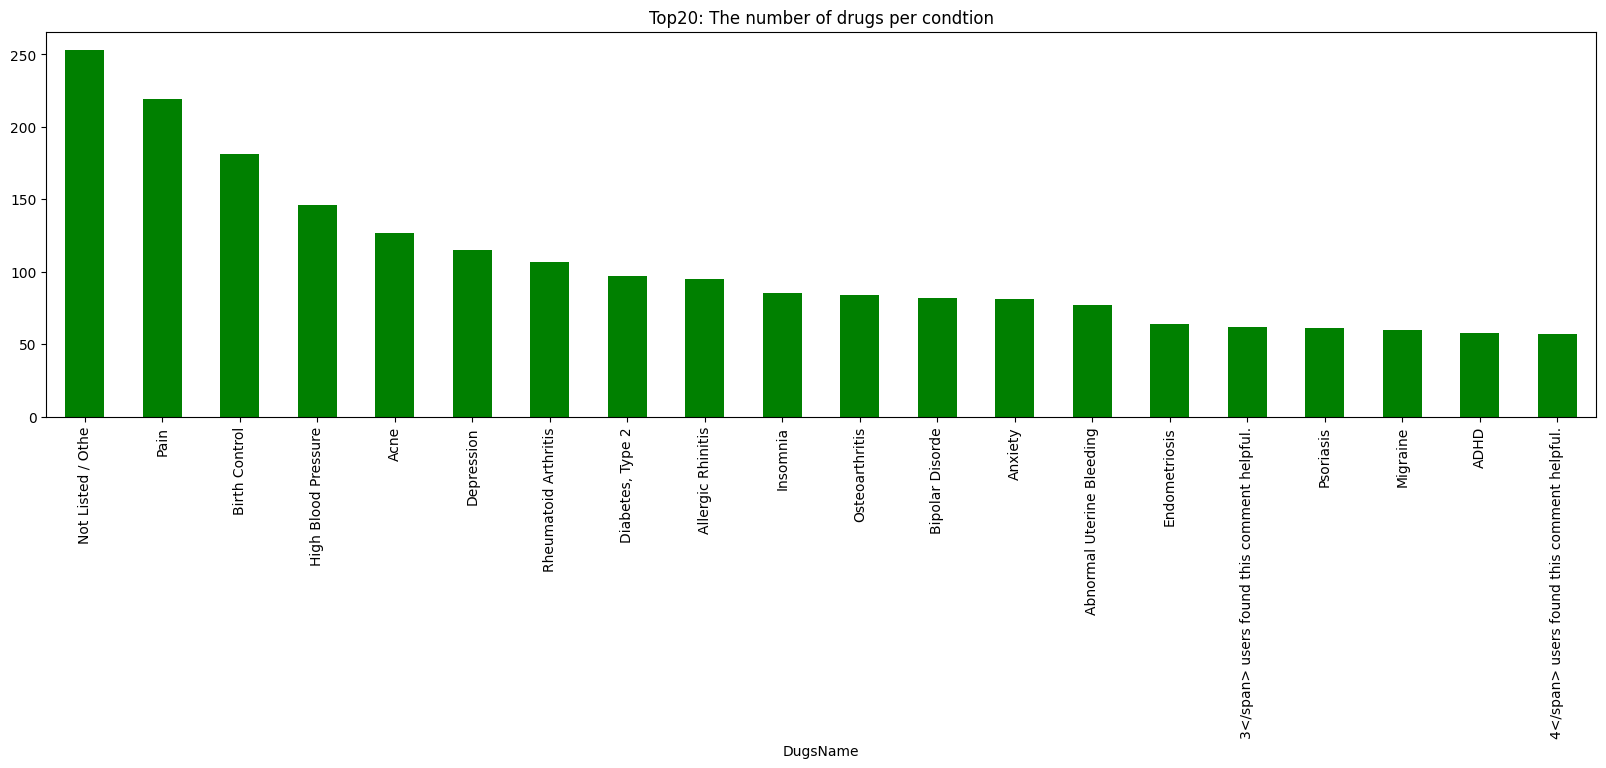

In [69]:
# Plotting 
# need to checktop 20 drugs accodring to condtion.. 
top20_drugs = df_all.groupby('condition')['drugName'].nunique().sort_values(ascending=False) 
top20_drugs[:20].plot(kind='bar',figsize=(20,5),color='green')
plt.xlabel('DugsName')
plt.title("Top20: The number of drugs per condtion")

Text(0.5, 1.0, 'Bottom20: The number of drugs per condtion')

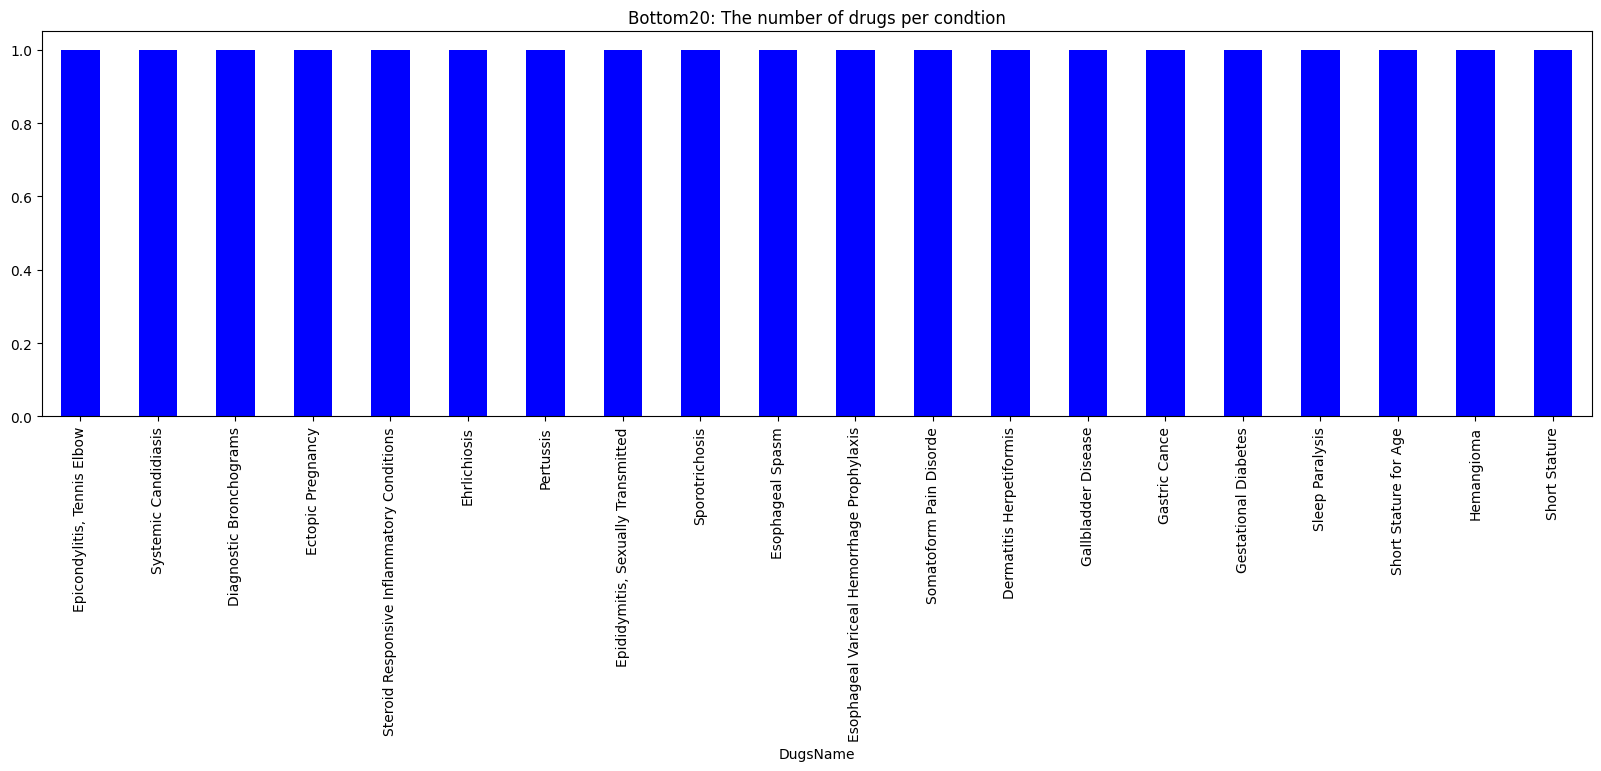

In [68]:
# Plotting 
# need to checktop 20 drugs accodring to condtion.. 
bottom20_drugs = df_all.groupby('condition')['drugName'].nunique().sort_values(ascending=True) 
bottom20_drugs[:20].plot(kind='bar',figsize=(20,5),color='blue')
plt.xlabel('DugsName')
plt.title("Bottom20: The number of drugs per condtion")

In [71]:
#  drug name with codntion which have more than 5 rtaing 
more_than5_rating = df_all[df_all['rating']>5]
lower_than5_rating = df_all[df_all['rating']<5]

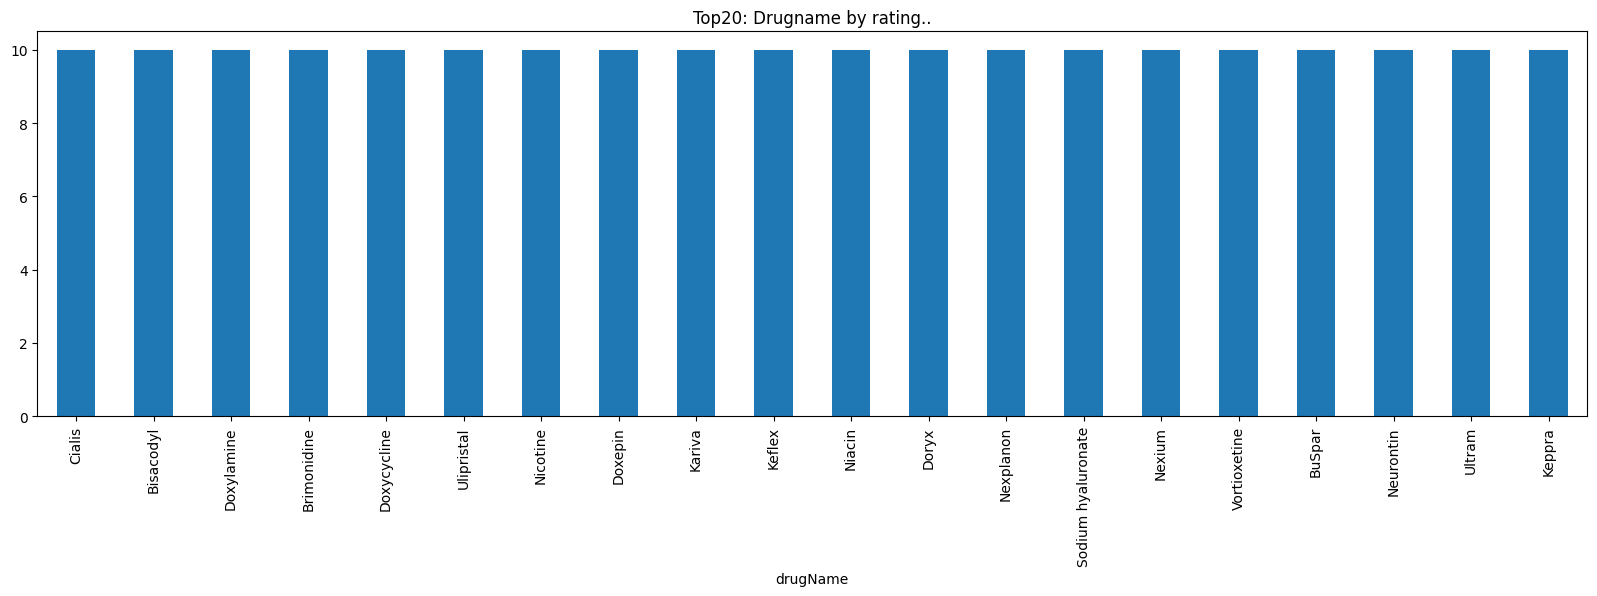

In [74]:
top_20_drugs_rating = df_all.groupby('drugName')['rating'].nunique().sort_values(ascending=False) 
top_20_drugs_rating[:20].plot(kind='bar',figsize=(20,5)) 
plt.xlabel('drugName')
plt.title('Top20: Drugname by rating..')
plt.show()

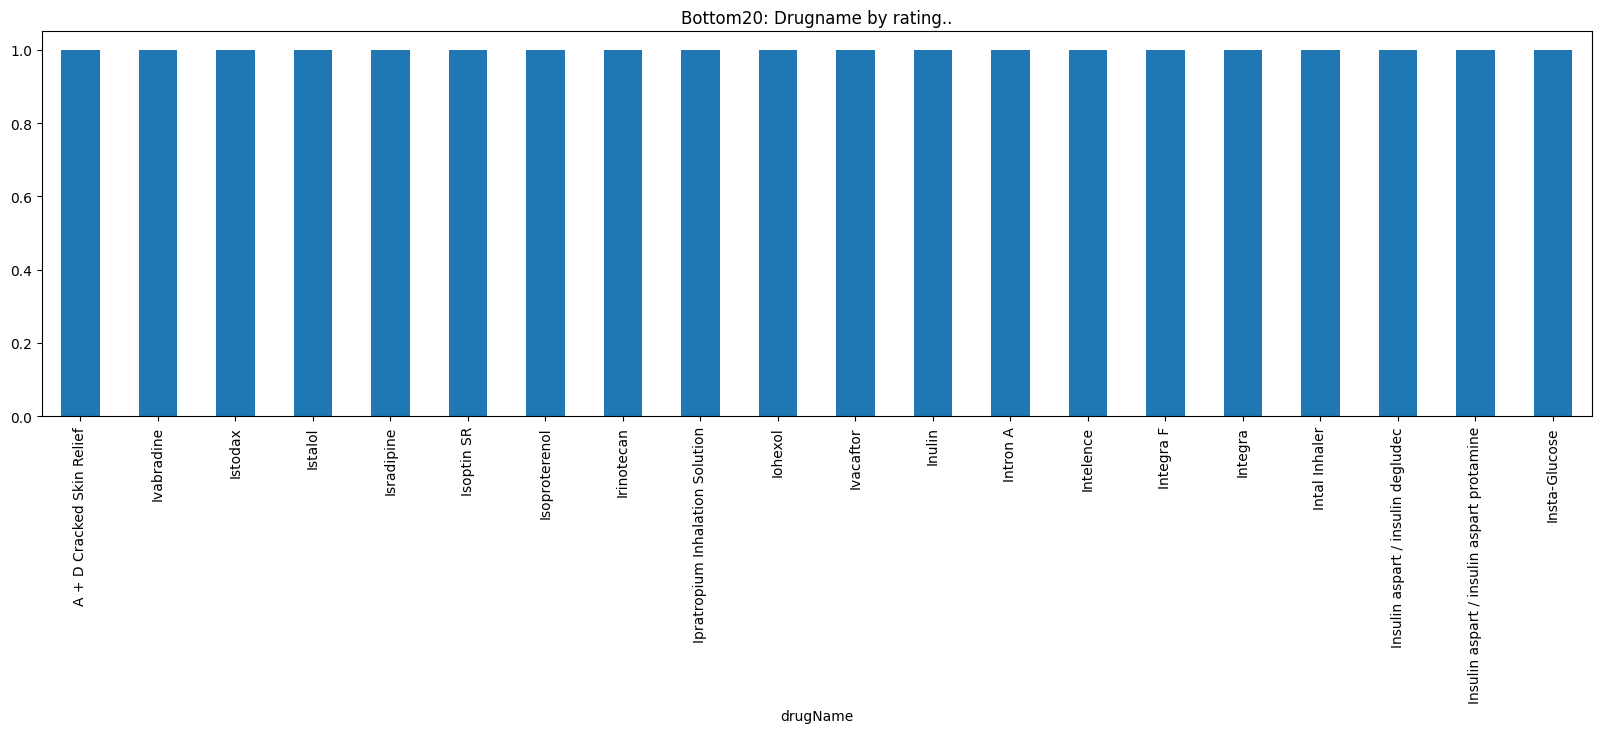

In [77]:
bottom_20_drugs_rating = df_all.groupby('drugName')['rating'].nunique().sort_values(ascending=True) 
bottom_20_drugs_rating[:20].plot(kind='bar',figsize=(20,5)) 
plt.xlabel('drugName')
plt.title('Bottom20: Drugname by rating..')
plt.show()